# Week 7 Executive Dashboard

## Objective

This notebook integrates Week 5 feature analysis and Week 6 reporting
pipeline outputs into an executive dashboard framework.

The dashboard provides:

- Platform health KPIs
- Sensor trends
- Anomaly monitoring
- Feature importance insights
- Operational recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
summary_path = Path(
    "../reports/W06_Aido_Rover_Report.md"
)

In [4]:
kpi_df = pd.read_csv(
    "../dashboard/data/rover_kpi_summary.csv"
)

kpi_df

,mean_battery_soc,fault_rate,mean_lidar_distance,wheel_torque_imbalance,anomaly_threshold,high_risk_count,max_anomaly_score
0,59.987492,0.0,8.445379,4.89065,0.348934,600,0.403913


In [5]:
rover_importance = pd.read_csv(
    "../dashboard/data/rover_feature_importance.csv"
)

rover_importance.head()

,feature,importance
0,battery_rolling_mean,0.070588
1,battery_rolling_std,0.070319
2,lidar_rolling_mean,0.067617
3,lidar_abs_rate_change,0.067353
4,lidar_rolling_std,0.067307


In [6]:
fari_importance = pd.read_csv(
    "../dashboard/data/fari_feature_importance.csv"
)

fari_importance.head()

,feature,importance
0,response_length,0.384714
1,sentiment_score,0.295451
2,topic_coherence,0.156744
3,latency_ms,0.096397
4,session_duration,0.066693


In [7]:
kpi_cards = {
    "Average Battery SOC":
        round(
            kpi_df["mean_battery_soc"][0],
            2
        ),

    "Fault Rate":
        round(
            kpi_df["fault_rate"][0] * 100,
            2
        ),

    "Average LiDAR Distance":
        round(
            kpi_df["mean_lidar_distance"][0],
            2
        ),

    "Anomaly Count":
        int(
            kpi_df["high_risk_count"][0]
        )
}


kpi_cards

{'Average Battery SOC': np.float64(59.99),
 'Fault Rate': np.float64(0.0),
 'Average LiDAR Distance': np.float64(8.45),
 'Anomaly Count': 600}

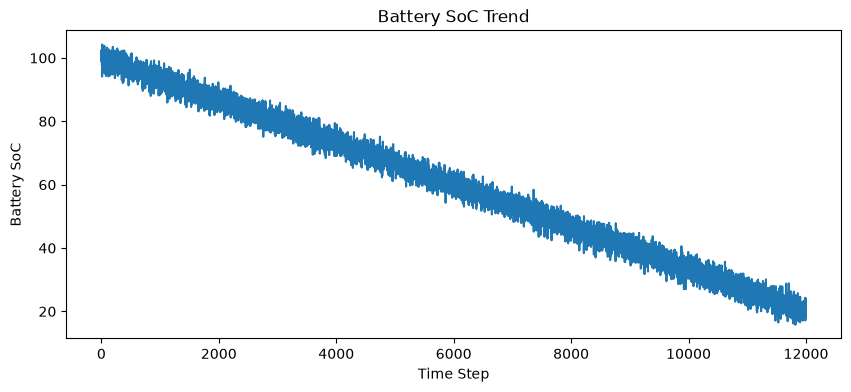

In [8]:
img_path = (
    "../dashboard/data/battery_soc_trend.png"
)


from IPython.display import Image

Image(
    filename=img_path
)

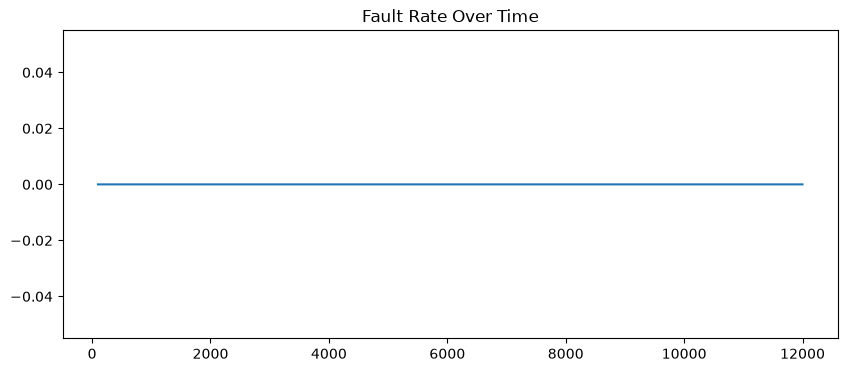

In [9]:
Image(
    filename=
    "../dashboard/data/fault_rate.png"
)

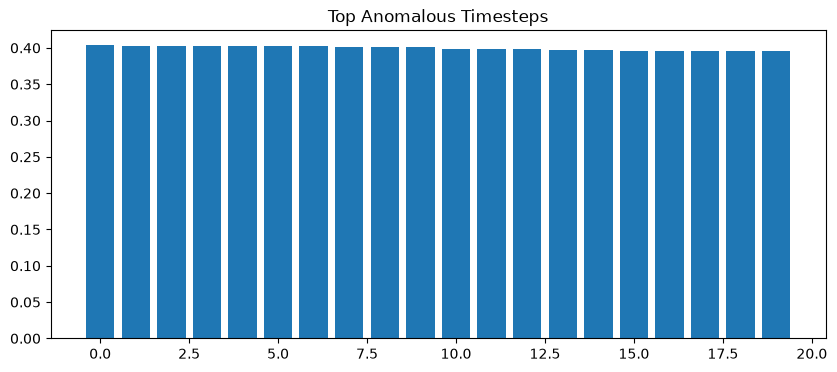

In [10]:
Image(
    filename=
    "../dashboard/data/top_anomalies.png"
)

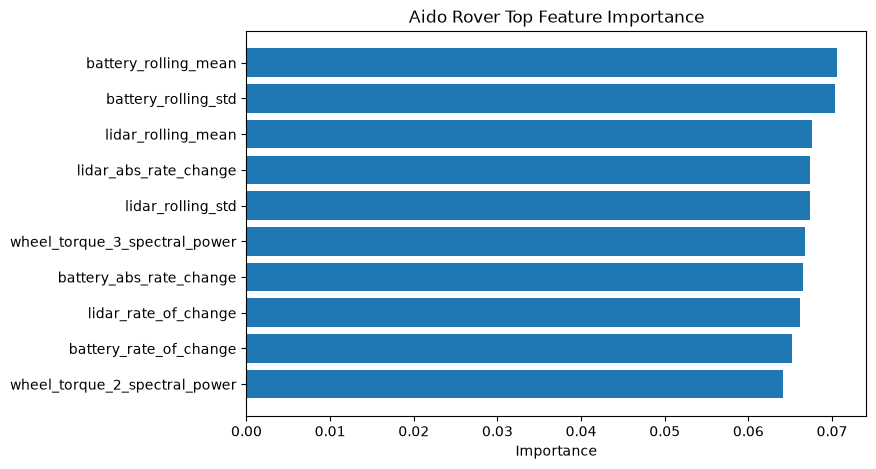

In [11]:
plt.figure(figsize=(8,5))


plt.barh(
    rover_importance.head(10)["feature"][::-1],
    rover_importance.head(10)["importance"][::-1]
)


plt.title(
    "Aido Rover Top Feature Importance"
)

plt.xlabel(
    "Importance"
)


plt.show()

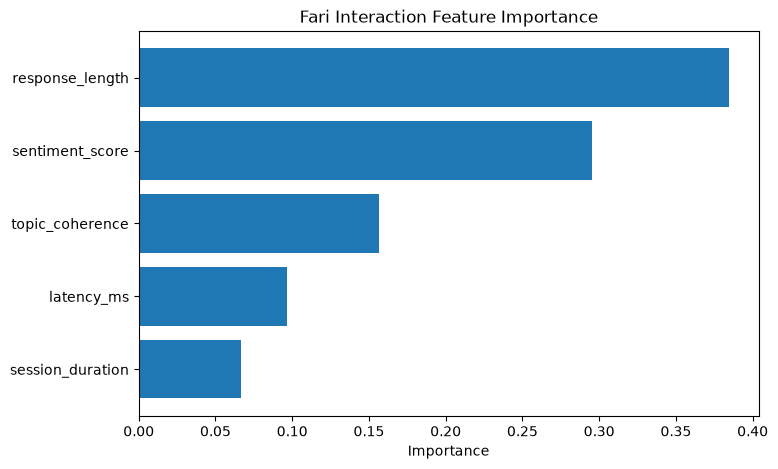

In [12]:
plt.figure(figsize=(8,5))


plt.barh(
    fari_importance["feature"][::-1],
    fari_importance["importance"][::-1]
)


plt.title(
    "Fari Interaction Feature Importance"
)


plt.xlabel(
    "Importance"
)


plt.show()

# Executive Insights


## Aido Rover

The dashboard indicates that Rover health depends on multiple sensor patterns.

Battery stability, LiDAR behavior, and wheel torque frequency features are
important indicators of operating condition.

Recommended actions:

- Monitor battery degradation
- Investigate high anomaly periods
- Review mechanical vibration patterns


## Fari

Interaction quality is mainly influenced by response length and sentiment.

Recommended actions:

- Improve response completeness
- Monitor user interaction quality
- Optimize conversational experience